# Predictive Maintenance for Defence & Critical Infrastructure: Production-Grade Equipment Failure ML

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predictive maintenance for defence platforms, critical infrastructure, and high-availability industrial systems

---

This notebook tackles one of the highest-value ML applications in defence and infrastructure: predicting equipment failure *before* it happens. In military contexts, unplanned downtime isn't just expensive — it degrades operational readiness and can compromise mission capability.

**Why predictive maintenance matters for Defence:**
- A grounded F-35 costs ~$44,000/hour in lost operational availability
- The ADF's fleet of 72 F-35As, 47 MRH-90s, and naval vessels all depend on condition-based maintenance
- CASG (Capability Acquisition and Sustainment Group) is actively investing in AI-driven sustainment
- Defence's Total Asset Management Framework mandates lifecycle cost optimization

**What this notebook demonstrates:**
- Multi-class failure mode classification (not just "will it fail?" but "*how* will it fail?")
- Binary failure prediction with cost-sensitive threshold tuning
- Sensor-driven feature engineering for condition monitoring
- Production deployment architecture for fleet-wide maintenance scheduling

**Notebook structure:**
1. Data Loading & Initial Assessment
2. Exploratory Data Analysis
3. Feature Engineering & Preprocessing
4. Failure Mode Analysis
5. Model Training & Comparison
6. Threshold Tuning & Cost-Sensitive Analysis
7. Model Interpretability
8. Production Deployment Considerations
9. Key Takeaways

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, brier_score_loss,
    classification_report
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb

import os
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Color scheme
COLOR_OK = '#2ecc71'       # Operational / no failure
COLOR_FAIL = '#e74c3c'     # Failure
COLOR_PALETTE = [COLOR_OK, COLOR_FAIL]
FAILURE_COLORS = {'TWF': '#e74c3c', 'HDF': '#e67e22', 'PWF': '#9b59b6', 'OSF': '#3498db', 'RNF': '#1abc9c'}

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Data Loading & Initial Assessment

The AI4I 2020 Predictive Maintenance Dataset is a synthetic dataset modelled after real industrial milling machine data. It contains 10,000 data points with sensor readings and five independent failure modes:

- **TWF** — Tool Wear Failure (tool replaced/failed at 200–240 min wear)
- **HDF** — Heat Dissipation Failure (thermal management issue)
- **PWF** — Power Failure (power outside 3500–9000W operating range)
- **OSF** — Overstrain Failure (torque × tool wear exceeds tolerance)
- **RNF** — Random Failure (0.1% chance, represents unpredictable events)

In a Defence context, think of these as analogous to: blade wear on helicopter rotors (TWF), engine overheating in armoured vehicles (HDF), power plant failures on naval vessels (PWF), structural fatigue on airframes (OSF), and random component failures (RNF).

In [2]:
# --- Data Loading: path discovery + load in ONE cell ---
csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            csv_path = os.path.join(root, f)
            break
    if csv_path:
        break

if csv_path is None:
    raise FileNotFoundError("No CSV found under /kaggle/input")

# Auto-detect separator
with open(csv_path, 'r') as fh:
    first_line = fh.readline()
sep = ';' if first_line.count(';') > first_line.count(',') else ','

df = pd.read_csv(csv_path, sep=sep)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Separator detected: '{sep}'")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded: /kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv
Shape: 10,000 rows × 14 columns
Separator detected: ','
Memory usage: 2.0 MB


In [3]:
# Schema overview
print("=" * 60)
print("SCHEMA OVERVIEW")
print("=" * 60)
print(f"\nColumns ({df.shape[1]}):")
for col in df.columns:
    dtype = df[col].dtype
    nunique = df[col].nunique()
    sample = df[col].iloc[0]
    print(f"  {col:<30} {str(dtype):<10} unique={nunique:<8} sample={sample}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.head()

SCHEMA OVERVIEW

Columns (14):
  UDI                            int64      unique=10000    sample=1
  Product ID                     object     unique=10000    sample=M14860
  Type                           object     unique=3        sample=M
  Air temperature [K]            float64    unique=93       sample=298.1
  Process temperature [K]        float64    unique=82       sample=308.6
  Rotational speed [rpm]         int64      unique=941      sample=1551
  Torque [Nm]                    float64    unique=577      sample=42.8
  Tool wear [min]                int64      unique=246      sample=0
  Machine failure                int64      unique=2        sample=0
  TWF                            int64      unique=2        sample=0
  HDF                            int64      unique=2        sample=0
  PWF                            int64      unique=2        sample=0
  OSF                            int64      unique=2        sample=0
  RNF                            int64      unique=2 

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Identify target and failure mode columns
# The dataset has 'Machine failure' (binary) and individual failure mode columns
# Detect columns programmatically
target_col = None
failure_mode_cols = []

for col in df.columns:
    if 'failure' in col.lower() and 'machine' in col.lower():
        target_col = col
    elif df[col].dtype in ['int64', 'float64'] and df[col].nunique() == 2 and col not in ['UDI']:
        if col not in ['Machine failure'] and df[col].mean() < 0.15 and df[col].mean() > 0:
            failure_mode_cols.append(col)

# Fallback detection
if target_col is None:
    for col in df.columns:
        if 'failure' in col.lower() or 'target' in col.lower():
            target_col = col
            break

print(f"Target column: {target_col}")
print(f"Failure mode columns: {failure_mode_cols}")

# Class distribution
class_counts = df[target_col].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

fail_count = class_counts[minority_class]
ok_count = class_counts[majority_class]
fail_pct = fail_count / len(df) * 100

print(f"\n{'='*60}")
print("CLASS DISTRIBUTION (Binary: Machine Failure)")
print(f"{'='*60}")
print(f"Operational ({majority_class}): {ok_count:,} ({ok_count/len(df)*100:.2f}%)")
print(f"Failure     ({minority_class}): {fail_count:,} ({fail_pct:.2f}%)")
print(f"Imbalance ratio: 1:{ok_count // fail_count}")

if failure_mode_cols:
    print(f"\nFailure Mode Breakdown:")
    for col in failure_mode_cols:
        count = df[col].sum()
        print(f"  {col}: {count} ({count/len(df)*100:.2f}%)")

Target column: Machine failure
Failure mode columns: ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

CLASS DISTRIBUTION (Binary: Machine Failure)
Operational (0): 9,661 (96.61%)
Failure     (1): 339 (3.39%)
Imbalance ratio: 1:28

Failure Mode Breakdown:
  TWF: 46 (0.46%)
  HDF: 115 (1.15%)
  PWF: 95 (0.95%)
  OSF: 98 (0.98%)
  RNF: 19 (0.19%)


---
## 2. Exploratory Data Analysis

Predictive maintenance EDA focuses on understanding the operating conditions that lead to failure. In Defence logistics, this maps directly to fleet readiness analytics — understanding which operating profiles accelerate component degradation.

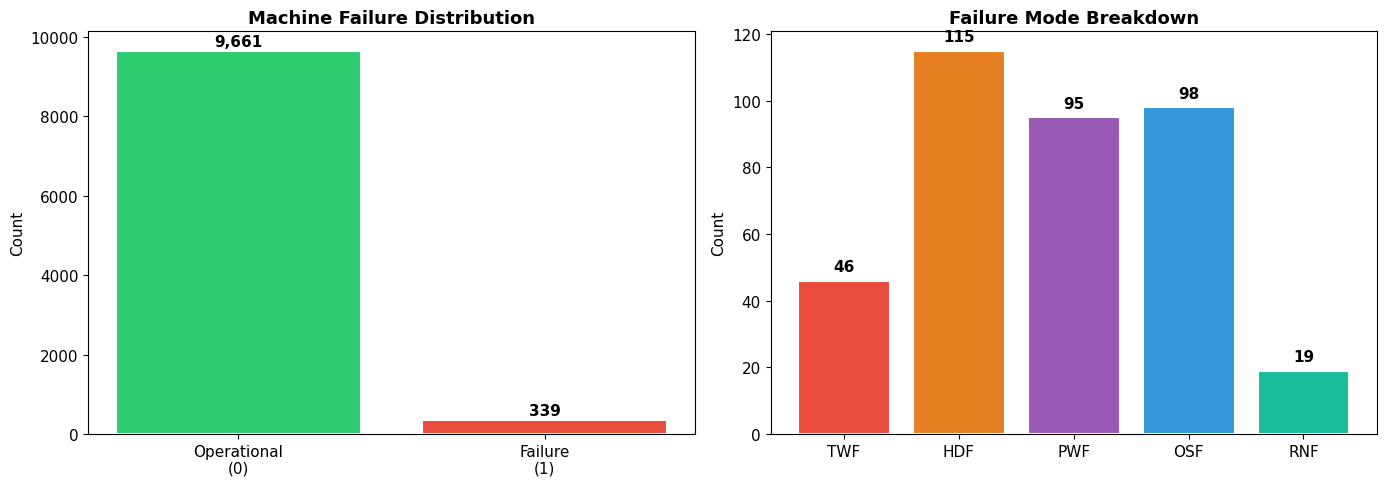


Note: Some failures have multiple modes simultaneously.
In Defence sustainment, understanding failure mode distribution drives spares provisioning.


In [5]:
# 2.1 Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary failure
bars = axes[0].bar([f'Operational\n({majority_class})', f'Failure\n({minority_class})'],
                    [ok_count, fail_count],
                    color=COLOR_PALETTE, edgecolor='white', linewidth=1.5)
axes[0].set_title('Machine Failure Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, [ok_count, fail_count]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Failure mode breakdown
if failure_mode_cols:
    mode_counts = {col: df[col].sum() for col in failure_mode_cols}
    mode_names = list(mode_counts.keys())
    mode_vals = list(mode_counts.values())
    mode_colors = [FAILURE_COLORS.get(n, '#95a5a6') for n in mode_names]
    axes[1].bar(mode_names, mode_vals, color=mode_colors, edgecolor='white', linewidth=1.5)
    axes[1].set_title('Failure Mode Breakdown', fontweight='bold')
    axes[1].set_ylabel('Count')
    for i, (name, val) in enumerate(zip(mode_names, mode_vals)):
        axes[1].text(i, val + 2, str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNote: Some failures have multiple modes simultaneously.")
print("In Defence sustainment, understanding failure mode distribution drives spares provisioning.")

Sensor/numeric features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Categorical features: ['Type']


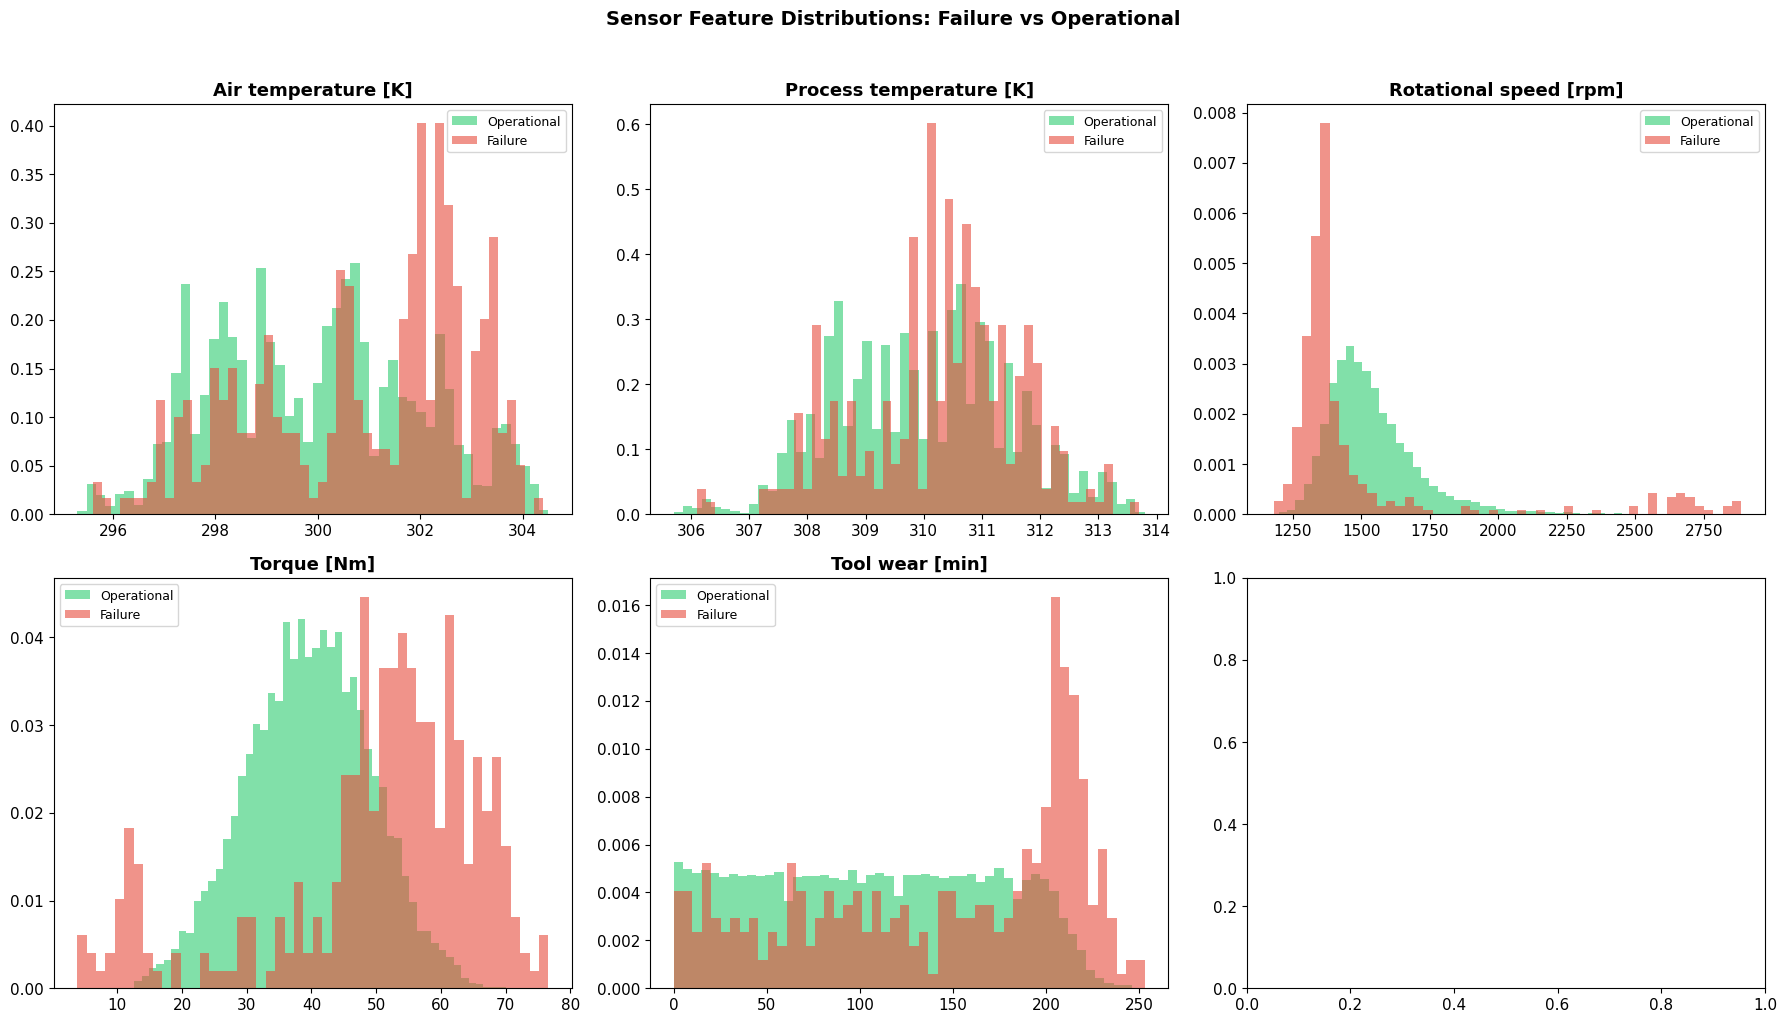

In [6]:
# 2.2 Sensor feature distributions — failure vs operational
# Identify numeric sensor columns (exclude IDs, target, failure modes)
exclude_cols = [target_col, 'UDI', 'Product ID'] + failure_mode_cols
sensor_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

# Also identify categorical columns
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c not in ['Product ID', 'UDI']]

print(f"Sensor/numeric features: {sensor_cols}")
print(f"Categorical features: {cat_cols}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, col in enumerate(sensor_cols[:6]):
    ax = axes_flat[idx]
    for cls, color, label in [(majority_class, COLOR_OK, 'Operational'),
                               (minority_class, COLOR_FAIL, 'Failure')]:
        subset = df[df[target_col] == cls][col]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(f'{col}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Sensor Feature Distributions: Failure vs Operational', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

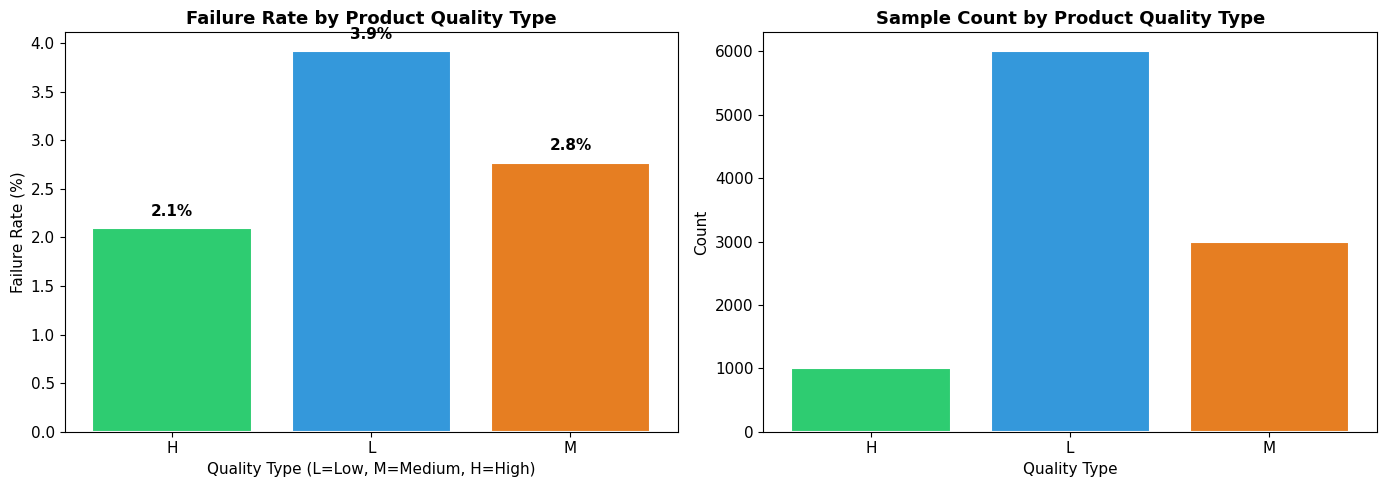


In Defence terms: L=commercial-off-the-shelf (COTS), M=mil-spec, H=mission-critical.
Higher-quality components have tighter tolerances but may still fail under extreme conditions.


In [7]:
# 2.3 Product quality type analysis
if cat_cols:
    type_col = cat_cols[0]  # 'Type' column
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Failure rate by product type
    type_failure = df.groupby(type_col)[target_col].agg(['mean', 'count']).reset_index()
    type_failure.columns = [type_col, 'failure_rate', 'count']
    
    type_colors = {'L': '#3498db', 'M': '#e67e22', 'H': '#2ecc71'}
    bars = axes[0].bar(type_failure[type_col], type_failure['failure_rate'] * 100,
                        color=[type_colors.get(t, '#95a5a6') for t in type_failure[type_col]],
                        edgecolor='white', linewidth=1.5)
    axes[0].set_title('Failure Rate by Product Quality Type', fontweight='bold')
    axes[0].set_ylabel('Failure Rate (%)')
    axes[0].set_xlabel('Quality Type (L=Low, M=Medium, H=High)')
    for bar, rate in zip(bars, type_failure['failure_rate']):
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                    f'{rate*100:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # Count by type
    axes[1].bar(type_failure[type_col], type_failure['count'],
                color=[type_colors.get(t, '#95a5a6') for t in type_failure[type_col]],
                edgecolor='white', linewidth=1.5)
    axes[1].set_title('Sample Count by Product Quality Type', fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].set_xlabel('Quality Type')
    
    plt.tight_layout()
    plt.show()
    
    print("\nIn Defence terms: L=commercial-off-the-shelf (COTS), M=mil-spec, H=mission-critical.")
    print("Higher-quality components have tighter tolerances but may still fail under extreme conditions.")

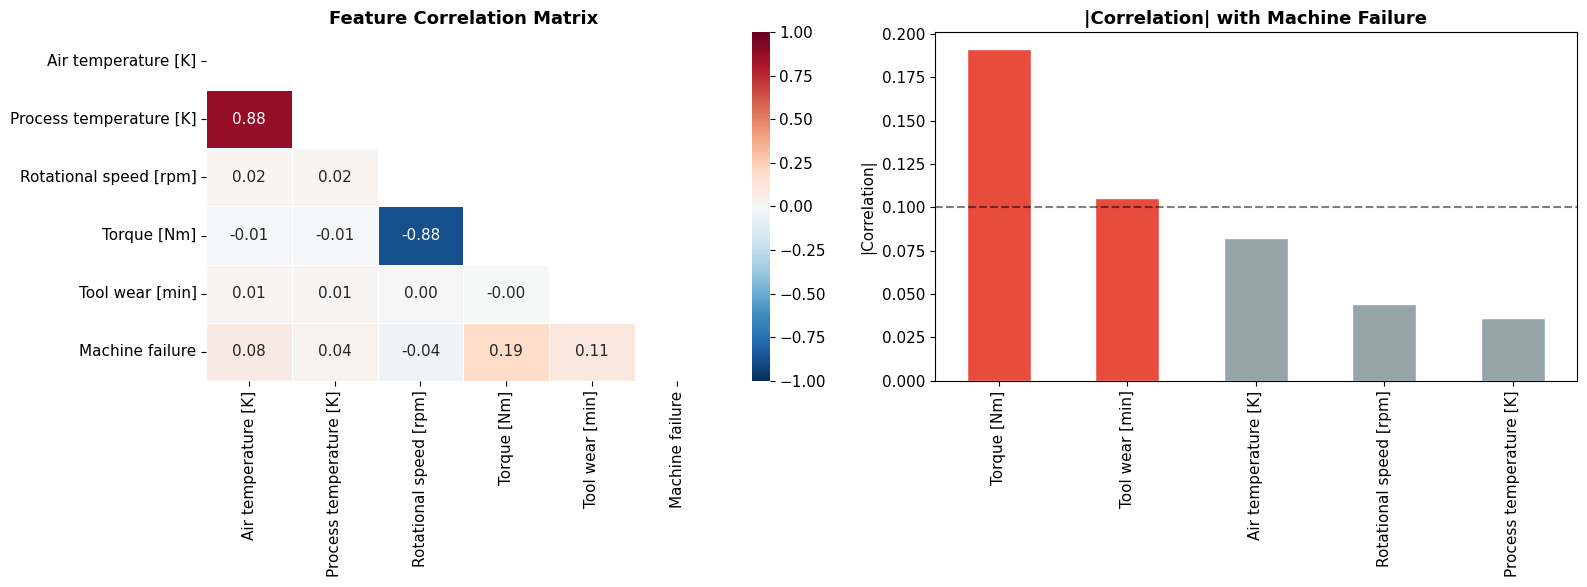

In [8]:
# 2.4 Correlation analysis
corr_cols = sensor_cols + [target_col]
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.5, linecolor='white',
            vmin=-1, vmax=1)
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')

# Correlation with target
target_corr = df[sensor_cols].corrwith(df[target_col]).abs().sort_values(ascending=False)
colors_corr = [COLOR_FAIL if c > 0.1 else '#95a5a6' for c in target_corr.values]
target_corr.plot(kind='bar', ax=axes[1], color=colors_corr, edgecolor='white')
axes[1].set_title('|Correlation| with Machine Failure', fontweight='bold')
axes[1].set_ylabel('|Correlation|')
axes[1].axhline(y=0.1, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

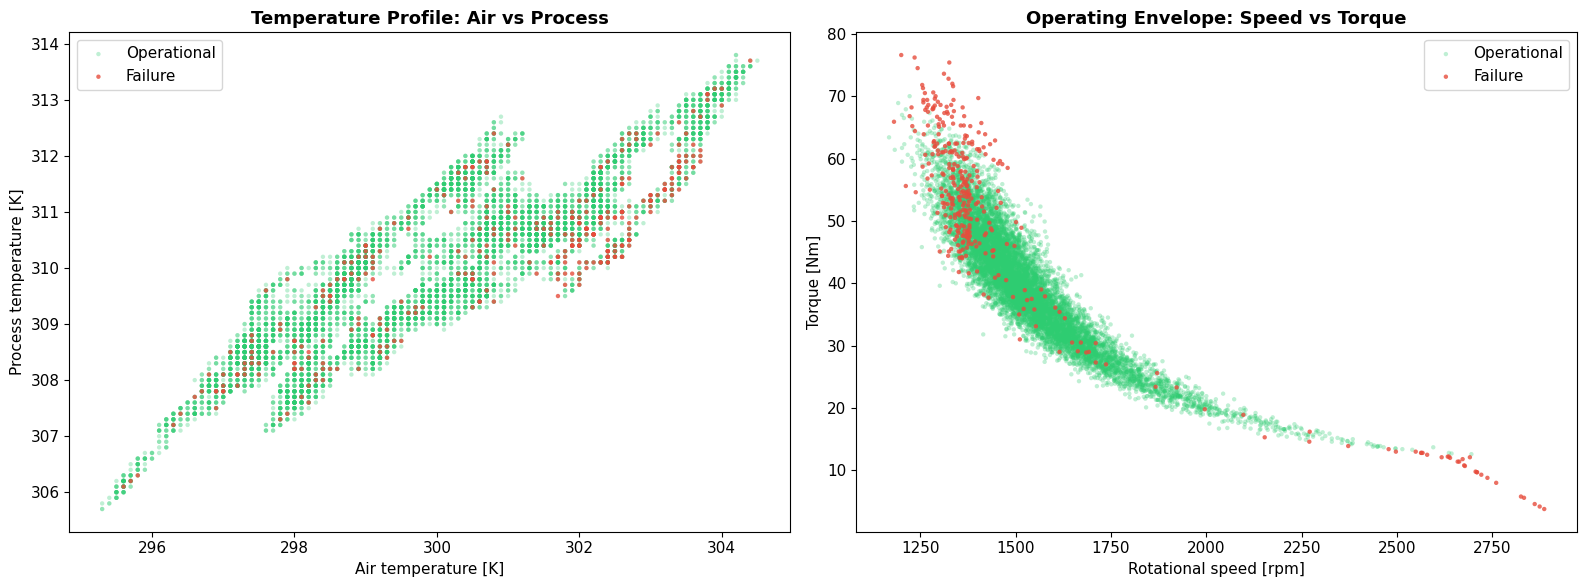


The operating envelope plot is critical in Defence maintenance — it shows the
boundary conditions where equipment operates under stress. Points outside the
normal operating envelope are prime candidates for condition-based alerts.


In [9]:
# 2.5 Sensor interaction patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temperature difference (process - air) is critical for HDF
temp_cols = [c for c in sensor_cols if 'temp' in c.lower() or 'Temp' in c]
if len(temp_cols) >= 2:
    ax = axes[0]
    for cls, color, label, alpha in [(majority_class, COLOR_OK, 'Operational', 0.3),
                                      (minority_class, COLOR_FAIL, 'Failure', 0.8)]:
        subset = df[df[target_col] == cls]
        ax.scatter(subset[temp_cols[0]], subset[temp_cols[1]], 
                  c=color, label=label, alpha=alpha, s=10, edgecolors='none')
    ax.set_xlabel(temp_cols[0])
    ax.set_ylabel(temp_cols[1])
    ax.set_title('Temperature Profile: Air vs Process', fontweight='bold')
    ax.legend()

# Torque vs rotational speed — power envelope
torque_cols = [c for c in sensor_cols if 'torque' in c.lower() or 'Torque' in c]
speed_cols = [c for c in sensor_cols if 'speed' in c.lower() or 'Speed' in c or 'rpm' in c.lower()]
if torque_cols and speed_cols:
    ax = axes[1]
    for cls, color, label, alpha in [(majority_class, COLOR_OK, 'Operational', 0.3),
                                      (minority_class, COLOR_FAIL, 'Failure', 0.8)]:
        subset = df[df[target_col] == cls]
        ax.scatter(subset[speed_cols[0]], subset[torque_cols[0]],
                  c=color, label=label, alpha=alpha, s=10, edgecolors='none')
    ax.set_xlabel(speed_cols[0])
    ax.set_ylabel(torque_cols[0])
    ax.set_title('Operating Envelope: Speed vs Torque', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

print("\nThe operating envelope plot is critical in Defence maintenance — it shows the")
print("boundary conditions where equipment operates under stress. Points outside the")
print("normal operating envelope are prime candidates for condition-based alerts.")

---
## 3. Feature Engineering & Preprocessing

In production predictive maintenance systems, feature engineering is where domain expertise meets data science. The raw sensor readings are useful, but *derived features* — temperature deltas, power calculations, cumulative wear indicators — are what drive model performance.

These engineered features map to real condition monitoring concepts:
- **Temperature delta** → thermal stress indicator (analogous to engine health monitoring)
- **Power** → mechanical load profile (torque × rotational speed)
- **Wear-adjusted torque** → cumulative stress exposure (like airframe fatigue hours)

In [10]:
# 3.1 Feature engineering
df_feat = df.copy()

# Identify key columns dynamically
temp_air = [c for c in df.columns if 'air' in c.lower() and 'temp' in c.lower()]
temp_proc = [c for c in df.columns if 'process' in c.lower() and 'temp' in c.lower()]
torque_col = [c for c in df.columns if 'torque' in c.lower()]
speed_col = [c for c in df.columns if 'speed' in c.lower() or 'rpm' in c.lower()]
wear_col = [c for c in df.columns if 'wear' in c.lower() and 'tool' in c.lower()]

print("Detected columns:")
print(f"  Air temp: {temp_air}")
print(f"  Process temp: {temp_proc}")
print(f"  Torque: {torque_col}")
print(f"  Speed: {speed_col}")
print(f"  Tool wear: {wear_col}")

# Temperature delta — thermal stress
if temp_air and temp_proc:
    df_feat['temp_delta'] = df_feat[temp_proc[0]] - df_feat[temp_air[0]]
    df_feat['temp_ratio'] = df_feat[temp_proc[0]] / df_feat[temp_air[0]].clip(lower=1)

# Power = torque * rotational speed (rad/s)
if torque_col and speed_col:
    df_feat['power_W'] = df_feat[torque_col[0]] * df_feat[speed_col[0]] * 2 * np.pi / 60
    df_feat['power_log'] = np.log1p(df_feat['power_W'].abs())

# Wear-adjusted torque — cumulative mechanical stress
if torque_col and wear_col:
    df_feat['wear_torque_product'] = df_feat[wear_col[0]] * df_feat[torque_col[0]]

# Torque-speed ratio (mechanical advantage)
if torque_col and speed_col:
    df_feat['torque_speed_ratio'] = df_feat[torque_col[0]] / df_feat[speed_col[0]].clip(lower=1)

# Tool wear squared — accelerating degradation
if wear_col:
    df_feat['wear_squared'] = df_feat[wear_col[0]] ** 2
    df_feat['wear_log'] = np.log1p(df_feat[wear_col[0]])

# Encode product type
if cat_cols:
    type_col = cat_cols[0]
    type_map = {t: i for i, t in enumerate(sorted(df_feat[type_col].unique()))}
    df_feat['type_encoded'] = df_feat[type_col].map(type_map)

new_features = [c for c in df_feat.columns if c not in df.columns]
print(f"\nEngineered {len(new_features)} new features: {new_features}")

Detected columns:
  Air temp: ['Air temperature [K]']
  Process temp: ['Process temperature [K]']
  Torque: ['Torque [Nm]']
  Speed: ['Rotational speed [rpm]']
  Tool wear: ['Tool wear [min]']

Engineered 9 new features: ['temp_delta', 'temp_ratio', 'power_W', 'power_log', 'wear_torque_product', 'torque_speed_ratio', 'wear_squared', 'wear_log', 'type_encoded']


In [11]:
# 3.2 Prepare feature matrix
drop_cols = [target_col, 'UDI', 'Product ID'] + failure_mode_cols + cat_cols
feature_cols = [c for c in df_feat.columns if c not in drop_cols 
                and df_feat[c].dtype in ['int64', 'float64', 'int32', 'float32']]

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(df_feat[feature_cols])
y = df_feat[target_col].values

print(f"Feature matrix: X={X.shape}, y={y.shape}")
print(f"Failure rate: {y.mean()*100:.2f}%")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  [{i:2d}] {col}")

Feature matrix: X=(10000, 14), y=(10000,)
Failure rate: 3.39%

Features (14):
  [ 0] Air temperature [K]
  [ 1] Process temperature [K]
  [ 2] Rotational speed [rpm]
  [ 3] Torque [Nm]
  [ 4] Tool wear [min]
  [ 5] temp_delta
  [ 6] temp_ratio
  [ 7] power_W
  [ 8] power_log
  [ 9] wear_torque_product
  [10] torque_speed_ratio
  [11] wear_squared
  [12] wear_log
  [13] type_encoded


---
## 4. Failure Mode Analysis

Understanding *how* equipment fails is as important as predicting *when*. Different failure modes require different maintenance responses:

| Mode | Analogy in Defence | Maintenance Response |
|------|-------------------|---------------------|
| TWF (Tool Wear) | Blade/rotor wear | Scheduled replacement based on usage hours |
| HDF (Heat Dissipation) | Engine overheating | Cooling system inspection, thermal paste |
| PWF (Power Failure) | Generator/power plant | Electrical system diagnostics |
| OSF (Overstrain) | Structural fatigue | Load reduction, structural inspection |
| RNF (Random) | Unpredictable failure | Redundancy, rapid spares availability |

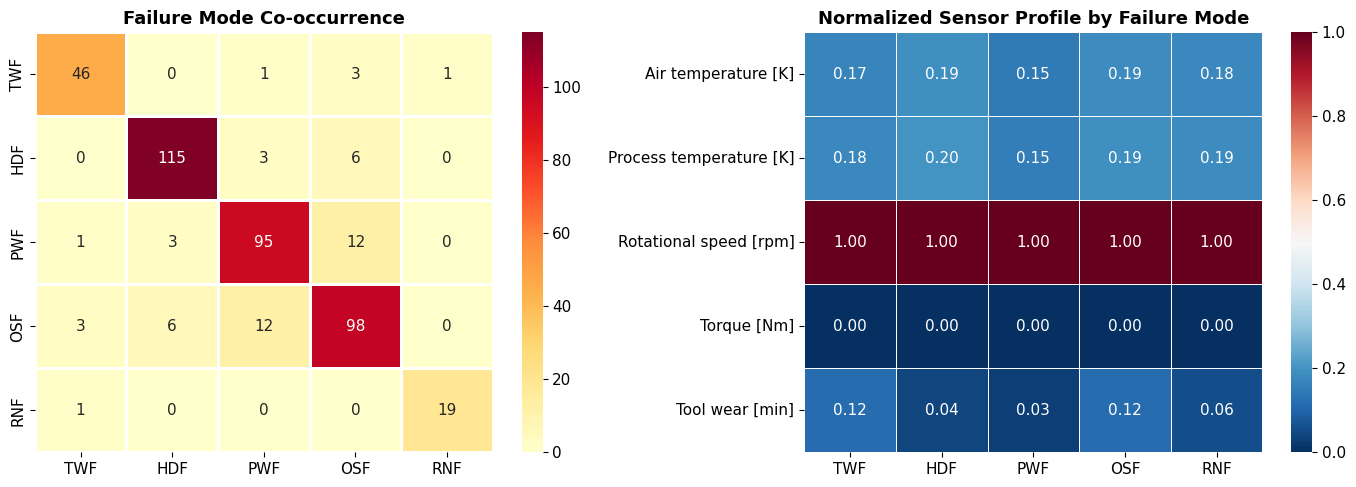


Failure mode signatures (mean sensor values when each mode is active):

  TWF (n=46):
    Torque [Nm]: 37.8 (↓5.4% vs overall)
    Tool wear [min]: 216.4 (↑100.4% vs overall)

  HDF (n=115):
    Rotational speed [rpm]: 1337.3 (↓13.1% vs overall)
    Torque [Nm]: 53.2 (↑33.0% vs overall)

  PWF (n=95):
    Rotational speed [rpm]: 1764.0 (↑14.6% vs overall)
    Torque [Nm]: 48.5 (↑21.3% vs overall)
    Tool wear [min]: 101.9 (↓5.6% vs overall)

  OSF (n=98):
    Rotational speed [rpm]: 1350.3 (↓12.2% vs overall)
    Torque [Nm]: 58.4 (↑46.0% vs overall)
    Tool wear [min]: 207.7 (↑92.4% vs overall)

  RNF (n=19):
    Rotational speed [rpm]: 1485.0 (↓3.5% vs overall)
    Torque [Nm]: 43.7 (↑9.2% vs overall)
    Tool wear [min]: 124.5 (↑15.3% vs overall)


In [12]:
# 4.1 Failure mode co-occurrence
if failure_mode_cols:
    # Co-occurrence matrix
    cooccur = df[failure_mode_cols].T.dot(df[failure_mode_cols])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(cooccur, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
                linewidths=1, linecolor='white')
    axes[0].set_title('Failure Mode Co-occurrence', fontweight='bold')
    
    # Failure mode profiles — mean sensor values
    mode_profiles = {}
    for mode in failure_mode_cols:
        mode_data = df[df[mode] == 1][sensor_cols].mean()
        mode_profiles[mode] = mode_data
    
    profile_df = pd.DataFrame(mode_profiles)
    # Normalize for comparison
    profile_norm = (profile_df - profile_df.min()) / (profile_df.max() - profile_df.min() + 1e-10)
    
    sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='RdBu_r', ax=axes[1],
                linewidths=0.5, linecolor='white', center=0.5)
    axes[1].set_title('Normalized Sensor Profile by Failure Mode', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\nFailure mode signatures (mean sensor values when each mode is active):")
    for mode in failure_mode_cols:
        vals = df[df[mode] == 1][sensor_cols].mean()
        print(f"\n  {mode} (n={df[mode].sum()}):")
        for col in sensor_cols:
            overall_mean = df[col].mean()
            mode_mean = vals[col]
            pct_diff = (mode_mean - overall_mean) / overall_mean * 100
            if abs(pct_diff) > 2:
                direction = "↑" if pct_diff > 0 else "↓"
                print(f"    {col}: {mode_mean:.1f} ({direction}{abs(pct_diff):.1f}% vs overall)")

Cohen's d: Statistical separation of sensor readings (Failure vs Operational)


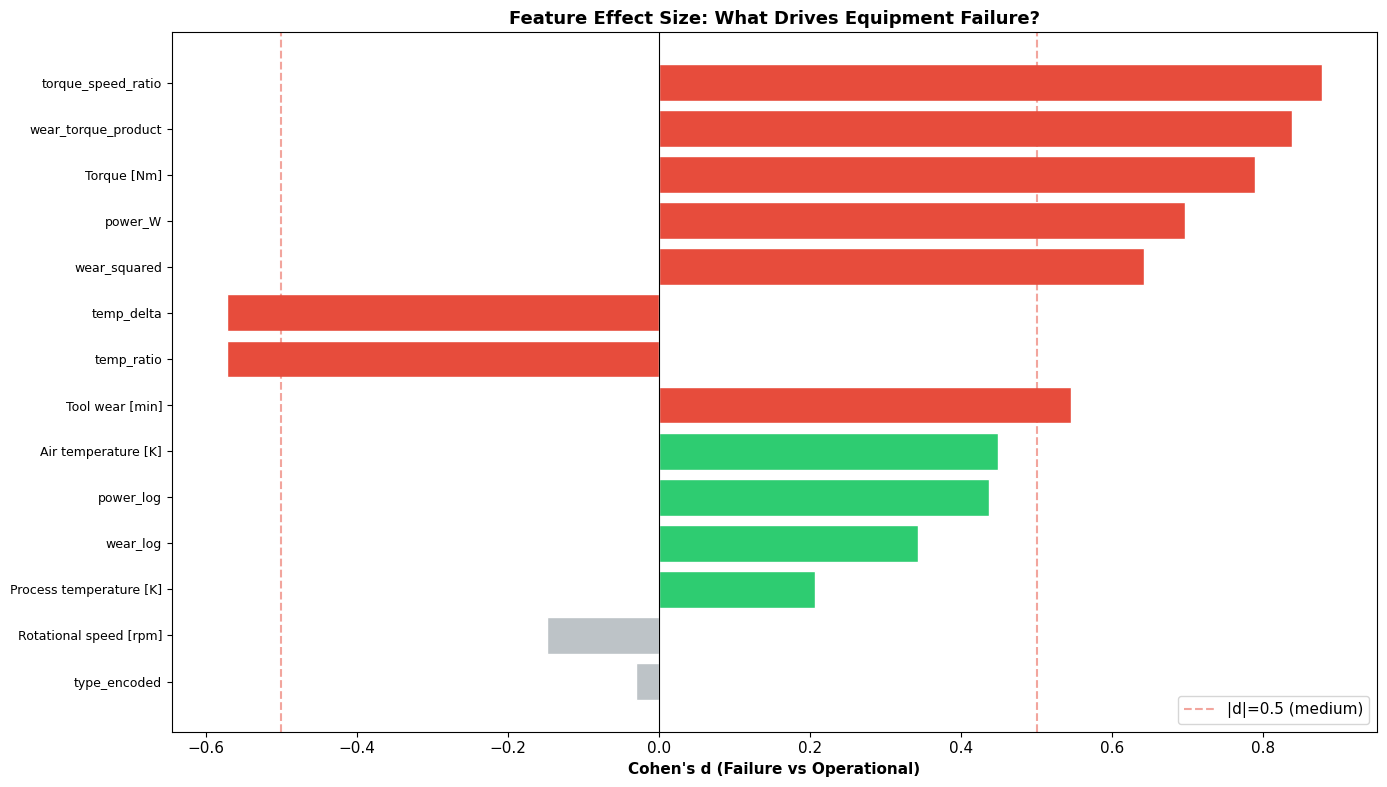


Top features by effect size:
  torque_speed_ratio         d = +0.878  (HIGHER in failures)
  wear_torque_product        d = +0.838  (HIGHER in failures)
  Torque [Nm]                d = +0.789  (HIGHER in failures)
  power_W                    d = +0.697  (HIGHER in failures)
  wear_squared               d = +0.642  (HIGHER in failures)
  temp_delta                 d = -0.572  (LOWER in failures)
  temp_ratio                 d = -0.572  (LOWER in failures)
  Tool wear [min]            d = +0.546  (HIGHER in failures)


In [13]:
# 4.2 Cohen's d — effect size for each sensor by failure mode
print("Cohen's d: Statistical separation of sensor readings (Failure vs Operational)")
print("=" * 70)

cohens_d_results = {}
for i, col in enumerate(feature_cols):
    ok_vals = X[y == majority_class, i]
    fail_vals = X[y == minority_class, i]
    
    ok_mean, fail_mean = ok_vals.mean(), fail_vals.mean()
    pooled_std = np.sqrt((ok_vals.std()**2 + fail_vals.std()**2) / 2)
    d = (fail_mean - ok_mean) / pooled_std if pooled_std > 0 else 0
    cohens_d_results[col] = d

sorted_effects = sorted(cohens_d_results.items(), key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(14, 8))
features_sorted = [x[0] for x in sorted_effects]
effects_sorted = [x[1] for x in sorted_effects]
colors = [COLOR_FAIL if abs(d) > 0.5 else COLOR_OK if abs(d) > 0.2 else '#bdc3c7' for d in effects_sorted]

ax.barh(range(len(features_sorted)), effects_sorted, color=colors, edgecolor='white')
ax.set_yticks(range(len(features_sorted)))
ax.set_yticklabels(features_sorted, fontsize=9)
ax.set_xlabel("Cohen's d (Failure vs Operational)", fontweight='bold')
ax.set_title("Feature Effect Size: What Drives Equipment Failure?", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.5, color=COLOR_FAIL, linestyle='--', alpha=0.5, label='|d|=0.5 (medium)')
ax.axvline(x=-0.5, color=COLOR_FAIL, linestyle='--', alpha=0.5)
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop features by effect size:")
for feat, d in sorted_effects[:8]:
    direction = "HIGHER in failures" if d > 0 else "LOWER in failures"
    print(f"  {feat:25s}  d = {d:+.3f}  ({direction})")

---
## 5. Model Training & Comparison

We train four models for binary failure prediction (will this machine fail on this run?):
1. **Logistic Regression** — interpretable baseline, fast inference for edge deployment
2. **Random Forest** — robust ensemble, handles sensor noise well
3. **XGBoost** — gradient boosting with `scale_pos_weight` for class imbalance
4. **LightGBM** — production-grade boosting, fastest inference

All use **3-fold stratified CV** with OOF predictions. Key metrics:
- **PR-AUC** — primary metric (imbalanced data)
- **Recall** — critical for maintenance: missed failures cause unplanned downtime
- **Precision** — unnecessary maintenance wastes resources and readiness

In [14]:
# 5.1 Model definitions
n_fail = (y == minority_class).sum()
n_ok = (y == majority_class).sum()
scale_ratio = n_ok / n_fail

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42,
        n_jobs=-1, max_depth=10, min_samples_leaf=5
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, scale_pos_weight=scale_ratio,
        random_state=42, eval_metric='logloss',
        max_depth=6, learning_rate=0.1, n_jobs=-1, verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=42, max_depth=-1, learning_rate=0.05,
        n_jobs=-1, verbose=-1, num_leaves=31, min_child_samples=5,
        reg_alpha=0.1, reg_lambda=1.0
    )
}

print(f"Class imbalance ratio: 1:{scale_ratio:.1f}")
print(f"Training samples: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"CV strategy: 3-fold StratifiedKFold")

Class imbalance ratio: 1:28.5
Training samples: 10,000
Features: 14
CV strategy: 3-fold StratifiedKFold


In [15]:
# 5.2 Manual 3-fold CV with OOF predictions
import time
from sklearn.base import clone

N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

results = {}
oof_preds = {}
oof_probs = {}

for model_name, model_template in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    oof_pred = np.zeros(len(y), dtype=int)
    oof_prob = np.zeros(len(y), dtype=float)
    fold_metrics = []
    start_time = time.time()
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model = clone(model_template)
        model.fit(X_train, y_train)
        
        pred = model.predict(X_val)
        prob = model.predict_proba(X_val)[:, 1]
        
        oof_pred[val_idx] = pred
        oof_prob[val_idx] = prob
        
        fold_f1 = f1_score(y_val, pred)
        fold_prauc = average_precision_score(y_val, prob)
        fold_rocauc = roc_auc_score(y_val, prob)
        fold_recall = recall_score(y_val, pred)
        fold_precision = precision_score(y_val, pred)
        
        print(f"  Fold {fold+1}: F1={fold_f1:.4f} | PR-AUC={fold_prauc:.4f} | "
              f"ROC-AUC={fold_rocauc:.4f} | Recall={fold_recall:.4f} | Prec={fold_precision:.4f}")
        
        fold_metrics.append({
            'f1': fold_f1, 'pr_auc': fold_prauc, 'roc_auc': fold_rocauc,
            'recall': fold_recall, 'precision': fold_precision
        })
    
    elapsed = time.time() - start_time
    
    oof_results = {
        'accuracy': accuracy_score(y, oof_pred),
        'precision': precision_score(y, oof_pred, zero_division=0),
        'recall': recall_score(y, oof_pred, zero_division=0),
        'f1': f1_score(y, oof_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, oof_prob),
        'pr_auc': average_precision_score(y, oof_prob),
        'brier': brier_score_loss(y, oof_prob),
        'time': elapsed,
        'fold_metrics': fold_metrics
    }
    
    results[model_name] = oof_results
    oof_preds[model_name] = oof_pred
    oof_probs[model_name] = oof_prob
    
    print(f"\n  OOF: F1={oof_results['f1']:.4f} | PR-AUC={oof_results['pr_auc']:.4f} | "
          f"ROC-AUC={oof_results['roc_auc']:.4f} | Time={elapsed:.1f}s")


Training: Logistic Regression
  Fold 1: F1=0.3046 | PR-AUC=0.4957 | ROC-AUC=0.9377 | Recall=0.8142 | Prec=0.1874
  Fold 2: F1=0.3274 | PR-AUC=0.4752 | ROC-AUC=0.9445 | Recall=0.8938 | Prec=0.2004
  Fold 3: F1=0.3232 | PR-AUC=0.5952 | ROC-AUC=0.9563 | Recall=0.8938 | Prec=0.1973

  OOF: F1=0.3185 | PR-AUC=0.5178 | ROC-AUC=0.9459 | Time=0.2s

Training: Random Forest
  Fold 1: F1=0.7750 | PR-AUC=0.8518 | ROC-AUC=0.9781 | Recall=0.8230 | Prec=0.7323
  Fold 2: F1=0.8571 | PR-AUC=0.8917 | ROC-AUC=0.9825 | Recall=0.8496 | Prec=0.8649
  Fold 3: F1=0.8205 | PR-AUC=0.8550 | ROC-AUC=0.9818 | Recall=0.8496 | Prec=0.7934

  OOF: F1=0.8166 | PR-AUC=0.8661 | ROC-AUC=0.9806 | Time=2.2s

Training: XGBoost
  Fold 1: F1=0.7745 | PR-AUC=0.8443 | ROC-AUC=0.9776 | Recall=0.8053 | Prec=0.7459
  Fold 2: F1=0.8017 | PR-AUC=0.8669 | ROC-AUC=0.9811 | Recall=0.8230 | Prec=0.7815
  Fold 3: F1=0.8151 | PR-AUC=0.8949 | ROC-AUC=0.9830 | Recall=0.8584 | Prec=0.7760

  OOF: F1=0.7972 | PR-AUC=0.8687 | ROC-AUC=0.9801 |

In [16]:
# 5.3 Results comparison
print("\n" + "=" * 95)
print("MODEL COMPARISON (OOF Results)")
print("=" * 95)
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>9} {'Brier':>8} {'Time':>7}")
print("-" * 95)

for name, res in results.items():
    print(f"{name:<22} {res['accuracy']:>9.4f} {res['precision']:>10.4f} {res['recall']:>8.4f} "
          f"{res['f1']:>8.4f} {res['roc_auc']:>9.4f} {res['pr_auc']:>9.4f} {res['brier']:>8.4f} {res['time']:>6.1f}s")

best_model = max(results.items(), key=lambda x: x[1]['pr_auc'])
print(f"\nBest model by PR-AUC: {best_model[0]} ({best_model[1]['pr_auc']:.4f})")


MODEL COMPARISON (OOF Results)
Model                   Accuracy  Precision   Recall       F1   ROC-AUC    PR-AUC    Brier    Time
-----------------------------------------------------------------------------------------------
Logistic Regression       0.8742     0.1951   0.8673   0.3185    0.9459    0.5178   0.0909    0.2s
Random Forest             0.9872     0.7939   0.8407   0.8166    0.9806    0.8661   0.0136    2.2s
XGBoost                   0.9857     0.7678   0.8289   0.7972    0.9801    0.8687   0.0117    0.7s
LightGBM                  0.9823     0.6995   0.8378   0.7624    0.9824    0.8750   0.0134    0.7s

Best model by PR-AUC: LightGBM (0.8750)


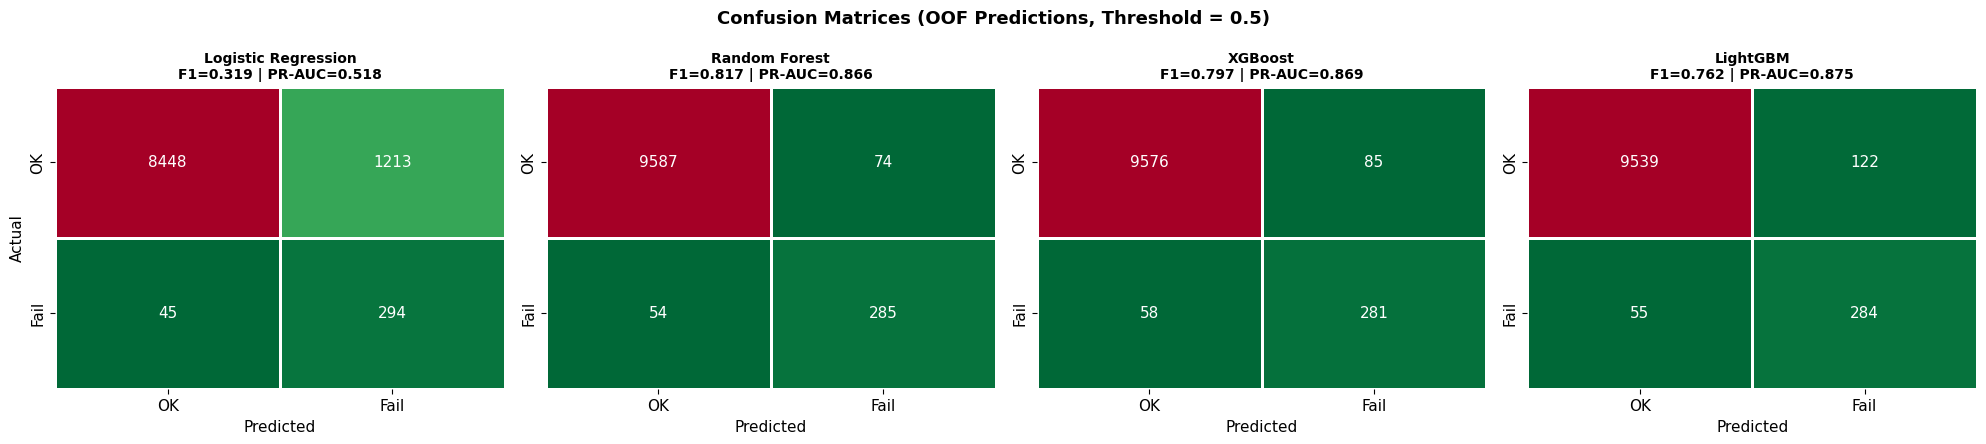

In [17]:
# 5.4 Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for idx, (name, pred) in enumerate(oof_preds.items()):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[idx],
                xticklabels=['OK', 'Fail'], yticklabels=['OK', 'Fail'],
                cbar=False, linewidths=1, linecolor='white')
    axes[idx].set_title(f'{name}\nF1={results[name]["f1"]:.3f} | PR-AUC={results[name]["pr_auc"]:.3f}',
                        fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Actual' if idx == 0 else '')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices (OOF Predictions, Threshold = 0.5)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

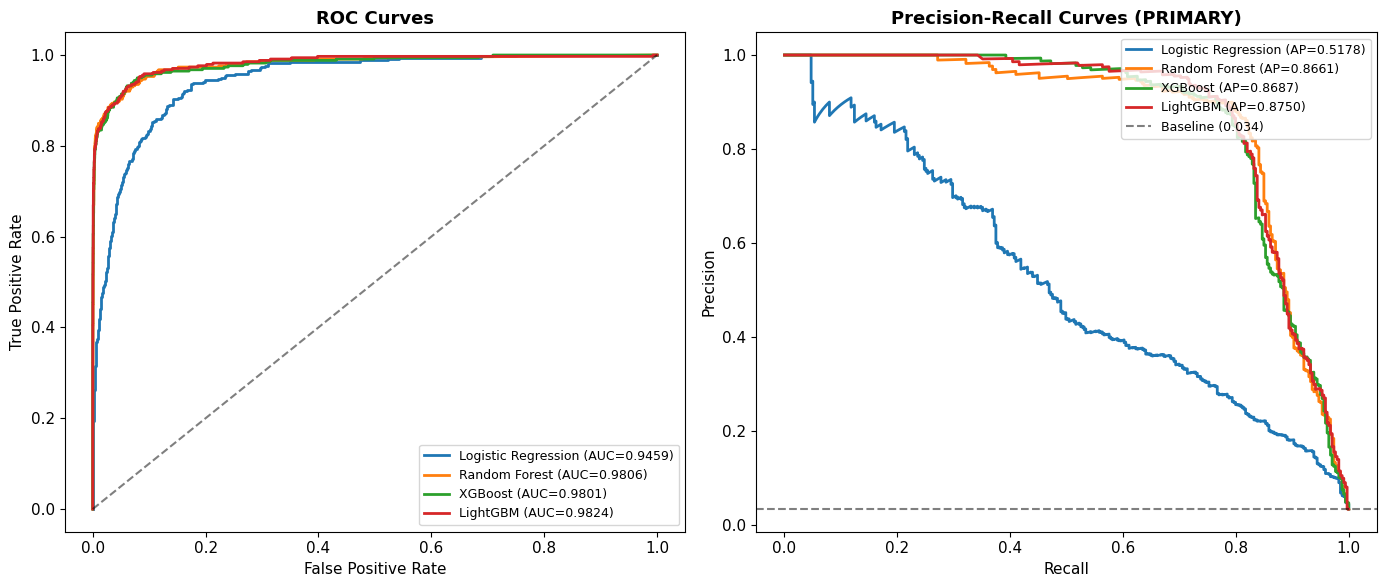

In [18]:
# 5.5 ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, prob in oof_probs.items():
    fpr, tpr, _ = roc_curve(y, prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.4f})", linewidth=2)
    
    prec, rec, _ = precision_recall_curve(y, prob)
    axes[1].plot(rec, prec, label=f"{name} (AP={results[name]['pr_auc']:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9, loc='lower right')

baseline = y.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline:.3f})')
axes[1].set_title('Precision-Recall Curves (PRIMARY)', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

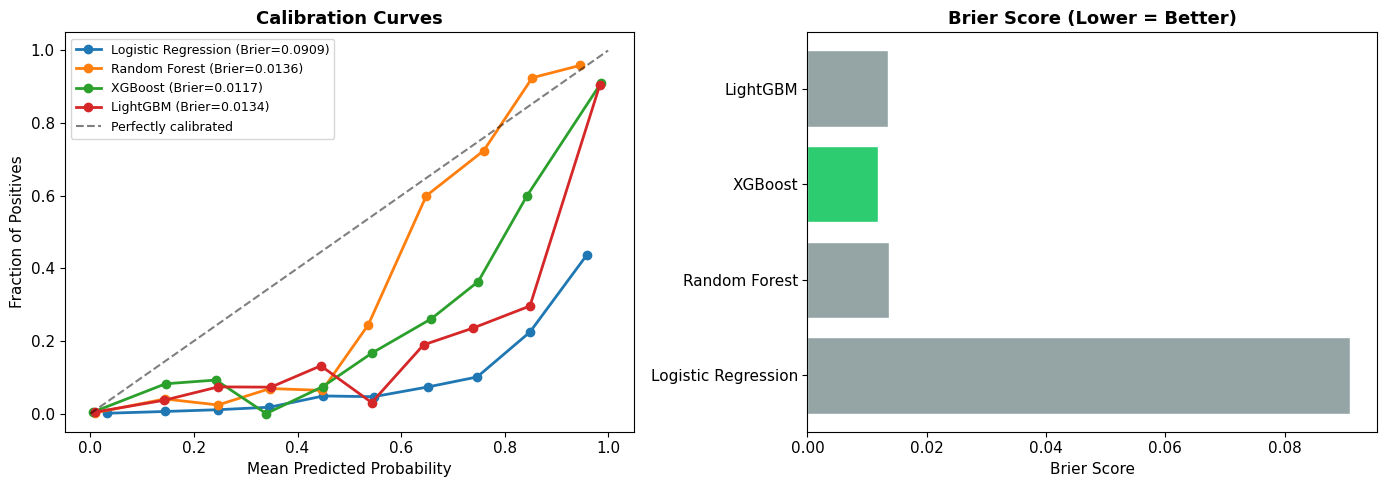

In [19]:
# 5.6 Calibration curves & Brier scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, prob in oof_probs.items():
    prob_true, prob_pred = calibration_curve(y, prob, n_bins=10, strategy='uniform')
    axes[0].plot(prob_pred, prob_true, marker='o', label=f"{name} (Brier={results[name]['brier']:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly calibrated')
axes[0].set_title('Calibration Curves', fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].legend(fontsize=9)

names = list(results.keys())
brier_scores = [results[n]['brier'] for n in names]
colors_b = [COLOR_OK if b == min(brier_scores) else '#95a5a6' for b in brier_scores]
axes[1].barh(names, brier_scores, color=colors_b, edgecolor='white')
axes[1].set_title('Brier Score (Lower = Better)', fontweight='bold')
axes[1].set_xlabel('Brier Score')

plt.tight_layout()
plt.show()

---
## 6. Threshold Tuning & Cost-Sensitive Analysis

In maintenance, the cost asymmetry is extreme:
- **False Negative** (missed failure) → unplanned downtime, potential catastrophic damage, mission failure
- **False Positive** (unnecessary maintenance) → wasted labour hours, unnecessary parts consumption, reduced availability

For Defence, the calculus depends on platform criticality:

| Platform | FN Cost | FP Cost | Optimal Bias |
|----------|---------|---------|-------------|
| Combat aircraft (F-35) | Catastrophic (mission abort) | High (aircraft grounded for inspection) | Balanced |
| Support vehicle (Bushmaster) | High (degraded capability) | Low (routine maintenance) | High recall |
| Base infrastructure (HVAC) | Low (inconvenience) | Very low (scheduled work) | Very high recall |

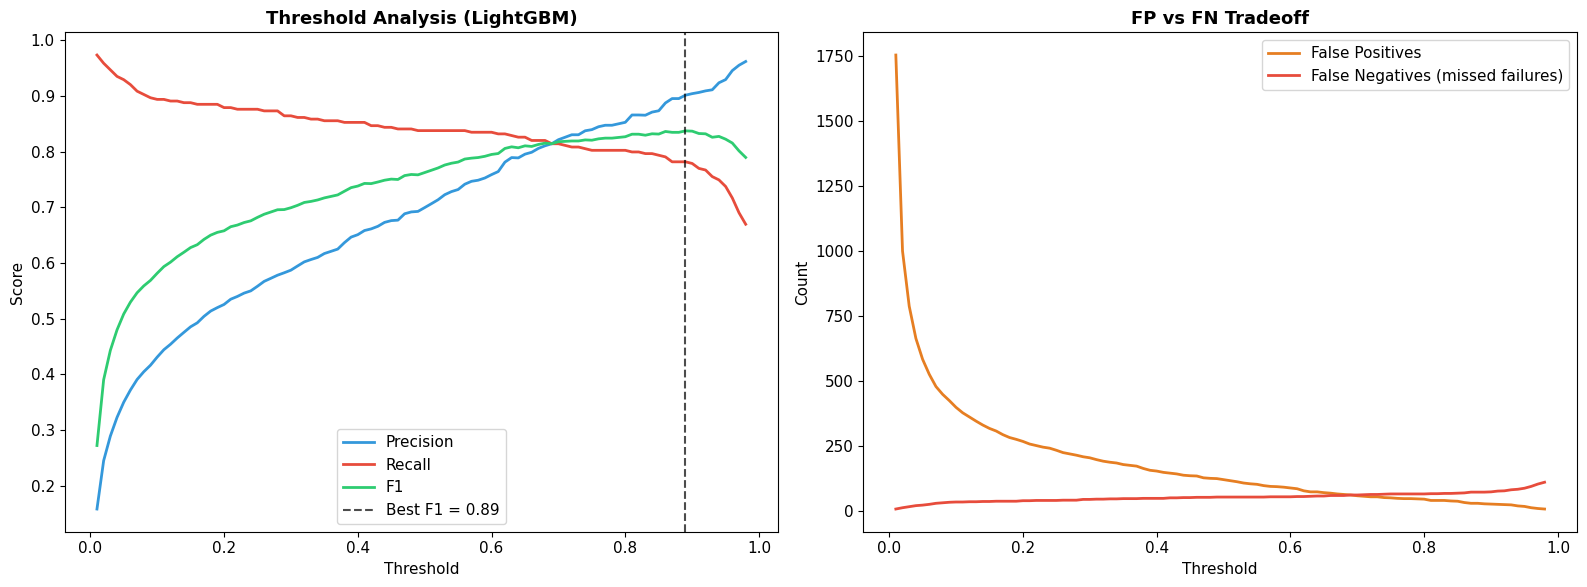

Optimal F1 threshold: 0.89


In [20]:
# 6.1 Threshold analysis
best_name = best_model[0]
best_prob = oof_probs[best_name]

thresholds = np.arange(0.01, 0.99, 0.01)
threshold_results = []

for thresh in thresholds:
    pred_t = (best_prob >= thresh).astype(int)
    tp = ((pred_t == 1) & (y == minority_class)).sum()
    fp = ((pred_t == 1) & (y == majority_class)).sum()
    fn = ((pred_t == 0) & (y == minority_class)).sum()
    tn = ((pred_t == 0) & (y == majority_class)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    threshold_results.append({
        'threshold': thresh, 'precision': prec, 'recall': rec, 'f1': f1,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    })

thr_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(thr_df['threshold'], thr_df['precision'], color='#3498db', label='Precision', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['recall'], color=COLOR_FAIL, label='Recall', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['f1'], color=COLOR_OK, label='F1', linewidth=2)
best_f1_idx = thr_df['f1'].idxmax()
best_f1_thresh = thr_df.loc[best_f1_idx, 'threshold']
axes[0].axvline(x=best_f1_thresh, color='black', linestyle='--', alpha=0.7,
                label=f'Best F1 = {best_f1_thresh:.2f}')
axes[0].set_title(f'Threshold Analysis ({best_name})', fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()

axes[1].plot(thr_df['threshold'], thr_df['fp'], color='#e67e22', label='False Positives', linewidth=2)
axes[1].plot(thr_df['threshold'], thr_df['fn'], color=COLOR_FAIL, label='False Negatives (missed failures)', linewidth=2)
axes[1].set_title('FP vs FN Tradeoff', fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Optimal F1 threshold: {best_f1_thresh:.2f}")

In [21]:
# 6.2 Cost-sensitive scenario analysis
# Cost assumptions (AUD, per event)
COST_FN_COMBAT = 50000    # Missed failure on combat platform — mission abort, emergency repair
COST_FN_SUPPORT = 15000   # Missed failure on support vehicle — degraded capability
COST_FN_INFRA = 2000      # Missed failure on base infrastructure
COST_FP = 500             # Unnecessary maintenance action (labour + parts + downtime)
COST_TP = 200             # Planned maintenance (cheaper than unplanned)

scenarios = {
    'Combat (F-35, recall-biased)': (0.15, COST_FN_COMBAT),
    'Balanced (Best F1)': (best_f1_thresh, COST_FN_SUPPORT),
    'Support Vehicle (Bushmaster)': (0.25, COST_FN_SUPPORT),
    'Base Infrastructure': (0.10, COST_FN_INFRA),
}

print("=" * 95)
print("COST-SENSITIVE SCENARIO ANALYSIS (Defence Platforms)")
print("=" * 95)
print(f"\n{'Scenario':<38} {'Thresh':>7} {'Recall':>8} {'Prec':>8} {'FP':>6} {'FN':>5} {'Est. Cost':>12}")
print("-" * 95)

for scenario_name, (thresh, fn_cost) in scenarios.items():
    row = thr_df.iloc[(thr_df['threshold'] - thresh).abs().argsort()[:1]].iloc[0]
    total_cost = row['fn'] * fn_cost + row['fp'] * COST_FP + row['tp'] * COST_TP
    print(f"{scenario_name:<38} {thresh:>7.2f} {row['recall']:>8.4f} {row['precision']:>8.4f} "
          f"{int(row['fp']):>6,} {int(row['fn']):>5,} ${total_cost:>10,.0f}")

print(f"\nKey: FN cost varies dramatically by platform criticality.")
print(f"A missed failure on an F-35 (mission abort) is 25x more costly than base HVAC.")

COST-SENSITIVE SCENARIO ANALYSIS (Defence Platforms)

Scenario                                Thresh   Recall     Prec     FP    FN    Est. Cost
-----------------------------------------------------------------------------------------------
Combat (F-35, recall-biased)              0.15   0.8879   0.4855    319    38 $ 2,119,700
Balanced (Best F1)                        0.89   0.7817   0.9014     29    74 $ 1,177,500
Support Vehicle (Bushmaster)              0.25   0.8761   0.5583    235    42 $   806,900
Base Infrastructure                       0.10   0.8938   0.4310    400    36 $   332,600

Key: FN cost varies dramatically by platform criticality.
A missed failure on an F-35 (mission abort) is 25x more costly than base HVAC.


---
## 7. Model Interpretability

Defence procurement and sustainment decisions require auditability. CASG and the Inspector-General ADF need to understand *why* a model recommends maintenance — you can't ground a $100M aircraft on a black-box prediction.

In [22]:
# 7.1 Feature importance extraction
importances = {}

lr_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr_final.fit(X, y)
importances['Logistic Regression'] = np.abs(lr_final.coef_[0])

rf_final = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42,
                                   n_jobs=-1, max_depth=10, min_samples_leaf=5)
rf_final.fit(X, y)
importances['Random Forest'] = rf_final.feature_importances_

xgb_final = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_ratio,
                                random_state=42, eval_metric='logloss',
                                max_depth=6, learning_rate=0.1, n_jobs=-1, verbosity=0)
xgb_final.fit(X, y)
importances['XGBoost'] = xgb_final.feature_importances_

lgb_final = lgb.LGBMClassifier(n_estimators=100, class_weight='balanced',
                                 random_state=42, max_depth=-1, learning_rate=0.05,
                                 n_jobs=-1, verbose=-1, num_leaves=31, min_child_samples=5,
                                 reg_alpha=0.1, reg_lambda=1.0)
lgb_final.fit(X, y)
importances['LightGBM'] = lgb_final.feature_importances_

print("Feature importances extracted from all 4 models.")

Feature importances extracted from all 4 models.


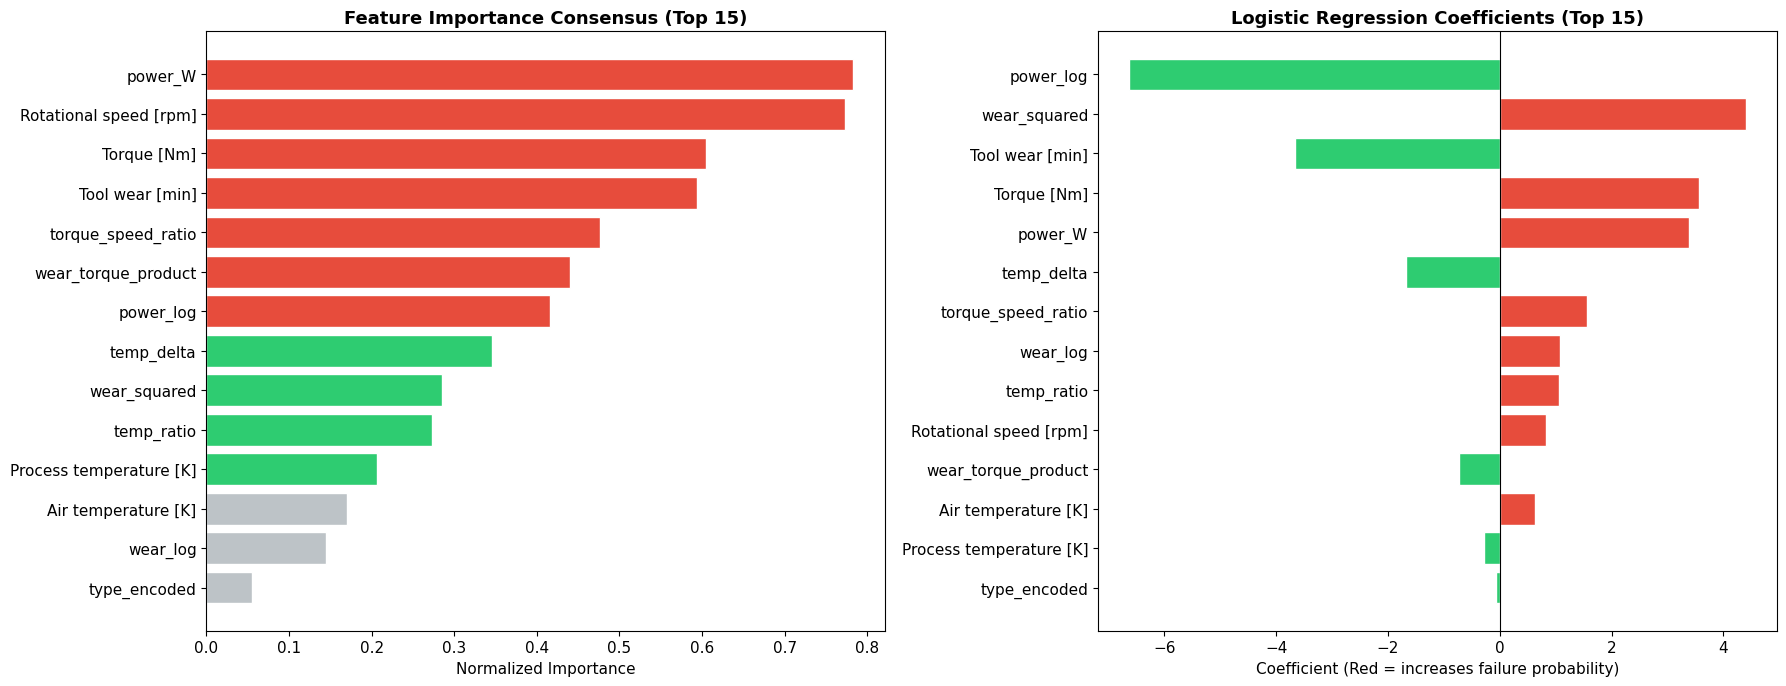


Interpretability for Defence stakeholders:
  Top 3 failure drivers: power_W, Rotational speed [rpm], Torque [Nm]
  These map directly to condition monitoring parameters in CASG sustainment contracts.


In [23]:
# 7.2 Consensus importance
norm_importances = {}
for name, imp in importances.items():
    imp_max = imp.max()
    norm_importances[name] = imp / imp_max if imp_max > 0 else imp

avg_importance = np.mean([norm_importances[m] for m in norm_importances], axis=0)
sorted_idx = np.argsort(avg_importance)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_features_names = [feature_cols[i] for i in sorted_idx]
top_features_vals = avg_importance[sorted_idx]
colors_imp = [COLOR_FAIL if v > 0.4 else COLOR_OK if v > 0.2 else '#bdc3c7' for v in top_features_vals]

axes[0].barh(range(len(top_features_names)), top_features_vals, color=colors_imp, edgecolor='white')
axes[0].set_yticks(range(len(top_features_names)))
axes[0].set_yticklabels(top_features_names)
axes[0].set_title('Feature Importance Consensus (Top 15)', fontweight='bold')
axes[0].set_xlabel('Normalized Importance')
axes[0].invert_yaxis()

# LR coefficients
lr_coefs = lr_final.coef_[0]
lr_sorted_idx = np.argsort(np.abs(lr_coefs))[::-1][:15]
lr_feat_names = [feature_cols[i] for i in lr_sorted_idx]
lr_coef_vals = lr_coefs[lr_sorted_idx]
lr_colors = [COLOR_FAIL if c > 0 else COLOR_OK for c in lr_coef_vals]

axes[1].barh(range(len(lr_feat_names)), lr_coef_vals, color=lr_colors, edgecolor='white')
axes[1].set_yticks(range(len(lr_feat_names)))
axes[1].set_yticklabels(lr_feat_names)
axes[1].set_title('Logistic Regression Coefficients (Top 15)', fontweight='bold')
axes[1].set_xlabel('Coefficient (Red = increases failure probability)')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nInterpretability for Defence stakeholders:")
print(f"  Top 3 failure drivers: {', '.join(top_features_names[:3])}")
print(f"  These map directly to condition monitoring parameters in CASG sustainment contracts.")

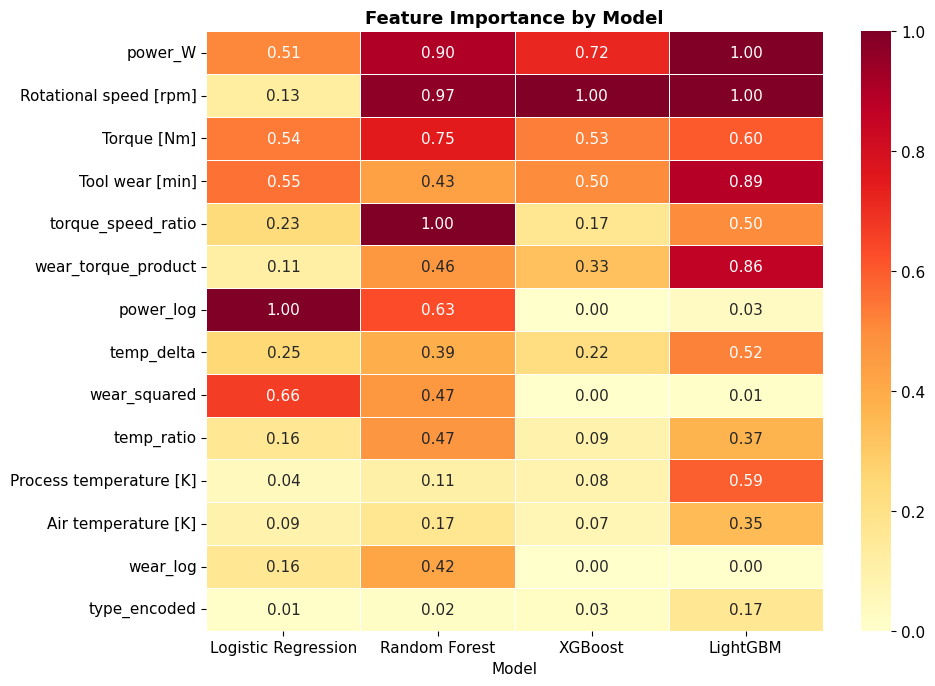

In [24]:
# 7.3 Per-model importance heatmap
top_n = min(15, len(feature_cols))
top_idx = np.argsort(avg_importance)[::-1][:top_n]
top_names = [feature_cols[i] for i in top_idx]

heatmap_data = pd.DataFrame({
    name: [norm_importances[name][i] for i in top_idx]
    for name in norm_importances
}, index=top_names)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
ax.set_title('Feature Importance by Model', fontweight='bold')
ax.set_xlabel('Model')
plt.tight_layout()
plt.show()

---
## 8. Production Deployment Considerations

Deploying predictive maintenance in a Defence environment involves unique constraints around security classification, network architecture, and regulatory compliance.

### Fleet-Wide Predictive Maintenance Architecture

```
Sensor Array (vibration, thermal, pressure, RPM)
    │
    ▼
Edge Gateway (on-platform / on-base)
    │ ── Encrypted telemetry (ACSM / DMS)
    ▼
Defence Data Hub (classified network)
    │
    ├── Real-Time Scoring Engine (<100ms)
    │       │
    │       ├── Score < Threshold ──► CONTINUE OPERATIONS
    │       ├── Score > Threshold ──► CONDITION ALERT → Maintenance Scheduler
    │       └── Score Critical ──► IMMEDIATE STAND-DOWN
    │
    ├── Batch Analytics (daily)
    │       ├── Fleet-wide health dashboard
    │       ├── Remaining useful life (RUL) estimation
    │       └── Spares demand forecasting
    │
    └── Model Registry & Retraining Pipeline
            ├── Champion/Challenger framework
            ├── Data drift monitoring (PSI, KS test)
            └── Model governance & audit trail
```

### Regulatory & Compliance Framework (Defence Context)

| Framework | Authority | Relevance |
|-----------|-----------|-----------|
| **DEFSTAN 00-970** | Defence | Airworthiness design requirements |
| **ASDEFCON** | CASG | Sustainment contract framework |
| **ISM (Information Security Manual)** | ASD | Data classification and handling |
| **Defence Total Asset Management** | Defence | Lifecycle cost optimization |
| **AS/NZS ISO 55001** | Standards Australia | Asset management systems |

### Key Production Considerations

**Edge Deployment:** Many Defence platforms operate in disconnected/denied environments (submarines, deployed land forces). Models must run on edge hardware with no cloud connectivity. This favours lightweight models (LR, small RF) over large ensembles.

**Data Classification:** Sensor data from Defence platforms is often PROTECTED or SECRET. Models trained on classified data cannot be moved to lower classification networks without sanitization review. Consider federated learning approaches where the model travels, not the data.

**Integration with Existing Systems:** Defence uses MILIS (Military Integrated Logistics Information System), CAMM2, and SAP/ROMAN for maintenance management. The ML scoring service must integrate with these systems via approved interfaces.

**Concept Drift:** Equipment degradation patterns change with operational tempo. A model trained during peacetime operations may not generalize to high-tempo deployments. Continuous monitoring with automated retraining triggers is essential.

**Human-in-the-Loop:** Maintenance decisions on safety-critical platforms always require engineering sign-off. The model provides a recommendation; the LAME (Licensed Aircraft Maintenance Engineer) or equivalent makes the call.

---
## 9. Key Takeaways

In [25]:
# Final summary
print("=" * 70)
print("PREDICTIVE MAINTENANCE — KEY RESULTS")
print("=" * 70)

print(f"\n1. DATASET: {len(df):,} machine runs, {fail_pct:.2f}% failure rate")
print(f"   Failure modes: {', '.join(failure_mode_cols)}")

print(f"\n2. BEST MODEL: {best_model[0]}")
print(f"   PR-AUC:   {best_model[1]['pr_auc']:.4f}  (PRIMARY metric)")
print(f"   ROC-AUC:  {best_model[1]['roc_auc']:.4f}")
print(f"   F1:       {best_model[1]['f1']:.4f}")
print(f"   Recall:   {best_model[1]['recall']:.4f}")

print(f"\n3. MODEL COMPARISON (PR-AUC):")
for name in sorted(results, key=lambda x: results[x]['pr_auc'], reverse=True):
    marker = " ◄ BEST" if name == best_model[0] else ""
    print(f"   {name:<22} {results[name]['pr_auc']:.4f}{marker}")

print(f"\n4. THRESHOLD ECONOMICS:")
print(f"   Optimal F1 threshold: {best_f1_thresh:.2f}")
print(f"   Combat platform (0.15): Maximum recall — never miss a failure")
print(f"   Support vehicle (0.25): Balanced — acceptable FP rate")
print(f"   Base infrastructure (0.10): Aggressive — maintenance is cheap")

print(f"\n5. TOP FEATURES (consensus):")
for i, feat in enumerate(top_features_names[:5]):
    print(f"   [{i+1}] {feat} (avg importance: {avg_importance[sorted_idx[i]]:.3f})")

print(f"\n6. PRODUCTION LESSONS:")
print(f"   • Failure mode classification enables targeted maintenance responses")
print(f"   • Edge deployment is critical for disconnected Defence environments")
print(f"   • Cost asymmetry varies 25x between combat and infrastructure platforms")
print(f"   • Human-in-the-loop is mandatory for safety-critical maintenance decisions")
print(f"   • Data classification (ISM) constrains model training and deployment architecture")
print(f"   • Integration with MILIS/CAMM2/SAP-ROMAN is the real deployment challenge")

print(f"\n{'='*70}")
print(f"Notebook by Dean | Lead Data & AI Engineer | Fujitsu Australia")
print(f"Part of the Production ML Portfolio Series:")
print(f"  [1] Network Intrusion Detection (Cybersecurity)")
print(f"  [2] Cardiovascular Disease Prediction (Healthcare)")
print(f"  [3] Credit Card Fraud Detection (Financial Crime)")
print(f"  [4] Predictive Maintenance (Defence & Infrastructure) ← This notebook")
print(f"{'='*70}")

PREDICTIVE MAINTENANCE — KEY RESULTS

1. DATASET: 10,000 machine runs, 3.39% failure rate
   Failure modes: TWF, HDF, PWF, OSF, RNF

2. BEST MODEL: LightGBM
   PR-AUC:   0.8750  (PRIMARY metric)
   ROC-AUC:  0.9824
   F1:       0.7624
   Recall:   0.8378

3. MODEL COMPARISON (PR-AUC):
   LightGBM               0.8750 ◄ BEST
   XGBoost                0.8687
   Random Forest          0.8661
   Logistic Regression    0.5178

4. THRESHOLD ECONOMICS:
   Optimal F1 threshold: 0.89
   Combat platform (0.15): Maximum recall — never miss a failure
   Support vehicle (0.25): Balanced — acceptable FP rate
   Base infrastructure (0.10): Aggressive — maintenance is cheap

5. TOP FEATURES (consensus):
   [1] power_W (avg importance: 0.783)
   [2] Rotational speed [rpm] (avg importance: 0.773)
   [3] Torque [Nm] (avg importance: 0.604)
   [4] Tool wear [min] (avg importance: 0.594)
   [5] torque_speed_ratio (avg importance: 0.477)

6. PRODUCTION LESSONS:
   • Failure mode classification enables targe